In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

Analysis sugestion:
### Como o mapa global de salários de dados mudou de 2020 a 2025
- Qual país teve o maior crescimento salarial nesse período? A ascensão do trabalho remoto após 2020 fez com que países que antes não eram polos de tecnologia se tornassem mais competitivos? Você pode criar um gráfico animado que mostra a mudança das médias salariais no mapa-múndi ano a ano
### O valor de se tornar um profissional sênior aumentou ou diminuiu desde 2020
- O "salto" salarial de Pleno para Sênior era maior em 2021 do que em 2024? Podemos analisar a inflação salarial para cada nível de experiência. Houve algum ano em que os salários de nível júnior cresceram mais rápido que os de sênior, talvez pelo aquecimento do mercado
### A estratégia de remuneração das startups em comparação com as grandes empresas mudou ao longo desses cinco anos
- erá que as startups foram super agressivas com salários durante o boom de 2021 e 2022, mas as grandes empresas se mostraram mais estáveis e com melhores médias em 2024? Você pode criar um gráfico de linhas mostrando a evolução da média salarial para cada porte de empresa, ano a ano
### Qual Cargo de Dados se Valorizou Mais


In [3]:
df = pd.read_csv('salaries.csv')

In [4]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Quality Analyst,60000,GBP,75949,GB,0,GB,M
1,2025,EN,FT,Data Quality Analyst,48000,GBP,60759,GB,0,GB,M
2,2025,SE,FT,Applied Scientist,266000,USD,266000,US,0,US,M
3,2025,SE,FT,Applied Scientist,204000,USD,204000,US,0,US,M
4,2025,SE,FT,Data Scientist,291000,USD,291000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
141561,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
141562,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
141563,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
141564,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [6]:
for col in df.columns:
    print('Column:', col)
    print('Data values', list(df[col].unique()))
    print('-'*50)

Column: work_year
Data values [2025, 2024, 2023, 2022, 2020, 2021]
--------------------------------------------------
Column: experience_level
Data values ['EN', 'SE', 'MI', 'EX']
--------------------------------------------------
Column: employment_type
Data values ['FT', 'CT', 'PT', 'FL']
--------------------------------------------------
Column: job_title
Data values ['Data Quality Analyst', 'Applied Scientist', 'Data Scientist', 'Manager', 'Software Engineer', 'Machine Learning Engineer', 'Machine Learning Scientist', 'Analyst', 'Power BI Developer', 'Engineer', 'Research Assistant', 'Director', 'AI Engineer', 'Tech Lead', 'Data Lead', 'Consultant', 'Data Manager', 'Developer', 'Solutions Architect', 'Head of Data', 'Data Analyst', 'Analytics Engineer', 'Data Visualization Engineer', 'Product Owner', 'Data Governance', 'Data Specialist', 'Architect', 'Product Manager', 'Data Engineer', 'Data Architect', 'Quantitative Researcher', 'Researcher', 'Staff Engineer', 'Engineering Manager

In [15]:
# lets remove outliers
q1 = df['salary'].quantile(0.25)
q3 = df['salary'].quantile(0.75)
iqr = q3 - q1
df_without_outliers = df[(df['salary'] >= (q1 - 1.5 * iqr)) & (df['salary'] <= (q3 + 1.5 * iqr))]
# std = df['salary'].std()
# mean = df['salary'].mean()
# superior_limit = mean + 3 * std
# inferior_limit = mean - 3 * std
# df_without_outliers = df[(df['salary'] < superior_limit) & (df['salary'] > inferior_limit)]

<Axes: xlabel='salary'>

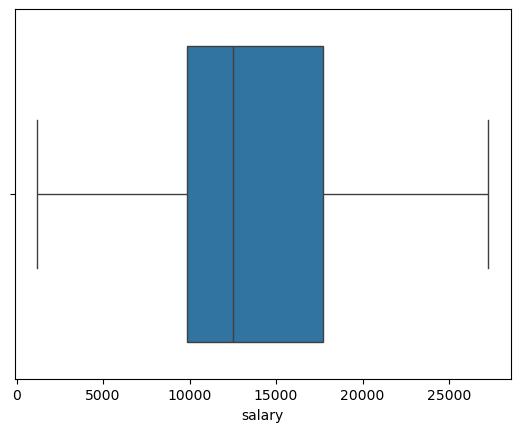

In [33]:
# sns.boxplot(x=df_without_outliers[df_without_outliers['company_size'] == 'M']['salary']/12)
sns.boxplot(x=df_without_outliers[df_without_outliers['company_size'] == 'L']['salary']/12)
# sns.boxplot(x=df_without_outliers[df_without_outliers['company_size'] == 'S']['salary']/12)

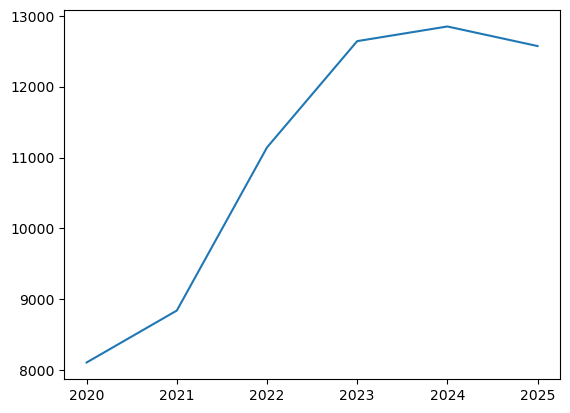

In [ ]:
mean_salary_by_year = df_without_outliers.groupby('work_year')['salary'].mean() / 12
plt.plot(mean_salary_by_year.index, mean_salary_by_year.values)
plt.show()